# Computational Optimization and Cosmological Parameter Estimation

## Inverse Transform Sampling, Differential Evolution, and Type Ia Supernovae

This notebook develops and applies numerical methods for scientific inference in astrophysics.

The analysis is organized around three connected computational problems:

1. **Inverse Transform Sampling** — generating random variates from a non-uniform probability density.
2. **Differential Evolution** — implementing and testing a population-based global optimization algorithm.
3. **Cosmological Parameter Estimation** — using Differential Evolution to minimize a $\chi^2$ objective for Type Ia supernova observations.

The notebook combines probability distributions, numerical optimization, vectorized computation, and observational cosmology into a single computational workflow.

### Methods

- Inverse transform sampling
- Probability density and cumulative distribution functions
- Differential Evolution
- Rosenbrock-function optimization
- Comparison with `scipy.optimize.differential_evolution`
- Type Ia supernova luminosity-distance modeling
- $\chi^2$ minimization and reduced $\chi^2$

> This notebook has been reformatted as a standalone portfolio project. Assignment prompts, grading information, and submission instructions have been removed while the original computational analysis is retained.


## Project Overview

The notebook begins with a controlled probability-distribution problem to demonstrate inverse transform sampling. The resulting samples are compared with the analytic probability density.

The second stage implements Differential Evolution from its underlying population-based update rule. The implementation is tested using the Rosenbrock function in multiple dimensions and compared against SciPy's established implementation.

The final stage applies the optimization method to a simple cosmological model. Type Ia supernova apparent magnitudes are compared with predictions based on luminosity distance in a `LambdaCDM` cosmology, and the matter and dark-energy density parameters are estimated by minimizing $\chi^2$.

### Computational workflow

**Probability model → Sampling → Optimization algorithm → Numerical validation → Cosmological model → Parameter estimation**


## 1. Computational Environment

The following cell imports the numerical, plotting, timing, and scientific-computing tools used throughout the notebook.

The plotting configuration is kept centralized so that the figures produced in later sections share a consistent presentation.


In [ ]:
import numpy as np 

# Configure Matplotlib for inline notebook figures.

import matplotlib.pyplot as plt
%matplotlib inline

# Define consistent figure-formatting defaults for the analysis.
def plot_prettier(dpi=150, fontsize=11, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

## 2. Inverse Transform Sampling

Consider the probability density

$$
g(x)=\frac{A}{\sqrt{x}},
$$

defined over a finite interval. The normalization constant $A$ is obtained by requiring

$$
\int g(x)\,dx = 1.
$$

The cumulative distribution function is then inverted to obtain a transformation from uniformly distributed random numbers to samples distributed according to $g(x)$.

This section implements the normalization, PDF, CDF, and inverse CDF and compares a large simulated sample with the analytic distribution.


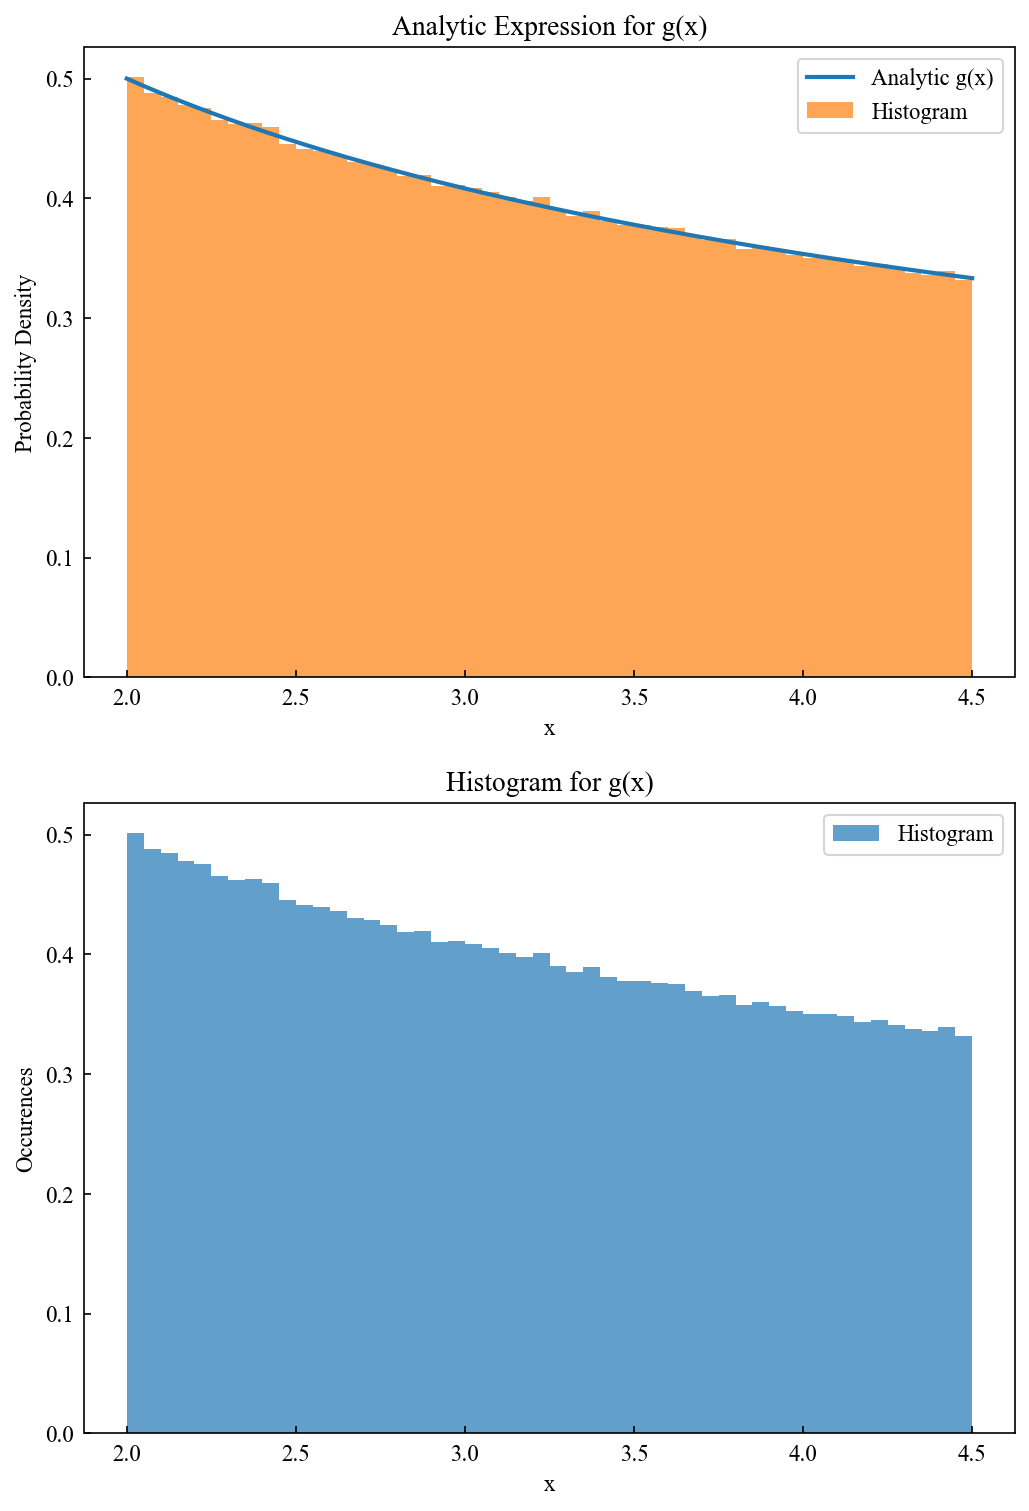

In [ ]:
# Normalization constant for the target probability density.
def norm_const(a):
    A = 1/ (2*a**0.5 - 2/a**0.5)
    return A 

# Target probability density and its cumulative distribution function.
def g(a,x):
    A = norm_const(a)
    return A/np.sqrt(x)
    
def cdf(a,x):
    A = norm_const(a)
    p_x = A*(2*x**0.5 - 2*a**0.5) 
    return p_x
def inv_cdf(a,y):  
    A = norm_const(a)
    x = (((y/A) + 2*a**0.5)/2)**2
    return x 
    
# Generate random samples using inverse transform sampling and compare them with the analytic PDF.
nr = 1e6
# generate nr uniformly distributed numbers over [0.,1.]
yrnd = np.random.uniform(0, 1, 1000000)

# Transform uniformly distributed samples into samples from g(x).
beta = 3.0
xcdf = inv_cdf(2, yrnd)
x_values = np.linspace(2, 4.5, 1000)
fig, axs = plt.subplots(2,1,figsize=(8, 12))
axs[0].plot(x_values, g(2,x_values), label='Analytic g(x)', linewidth=2)
axs[0].hist(xcdf, bins=50, density=True, alpha=0.7, label='Histogram')
axs[0].set_title('Analytic Expression for g(x)')
axs[0].set_xlabel('x')
axs[0].set_ylabel('Probability Density')
axs[0].legend()
axs[1].hist(xcdf, bins=50, density=True, alpha=0.7, label='Histogram')
axs[1].set_title('Histogram for g(x)')
axs[1].set_xlabel('x')
axs[1].set_ylabel('Occurences')
axs[1].legend()

plt.show()

## 3. Differential Evolution

Differential Evolution (DE) is a population-based global optimization method introduced by Storn and Price.

Rather than following a local gradient, DE maintains a population of candidate solutions. New candidates are generated from differences between existing population members and are retained when they improve the objective function.

This makes DE useful for nonlinear, multidimensional problems where the objective function may have complicated geometry.

The implementation below follows the basic mutation-and-selection form of the algorithm and is subsequently tested against the Rosenbrock function.


### 3.1 Differential-Evolution Update Strategy

For each population member, three distinct members of the current population are selected. A trial vector is constructed from a base member plus a scaled difference between two other population members.

The candidate replaces the current solution when it produces a lower objective-function value.

The implementation uses:

- a population of candidate parameter vectors,
- bounded initialization,
- a randomly selected scale factor,
- an absolute convergence tolerance,
- greedy selection of improved candidates.


### 3.2 Differential-Evolution Implementation

The following function implements the basic Differential Evolution minimizer used for the numerical experiments below.

The function accepts a general objective function, an initial population, convergence tolerance, scale-factor range, and parameter bounds.


### Population Initialization

For bounded optimization, the initial population is generated within the specified rectangular parameter domain.

This provides broad coverage of the search space before the evolutionary updates begin.


### 3.3 Optimization Test Problem

The **Rosenbrock function**, commonly called the "banana function," provides a useful benchmark for nonlinear optimization because its curved valley can be difficult for optimization algorithms to navigate.

The global minimum occurs at

$$
x_i=1
$$

for every dimension, where the function value is zero.

The implementation is tested in both two and five dimensions, allowing the effect of dimensionality and population size to be examined.


The two versions of the Rosenbrock 

In [ ]:
# Scalar Rosenbrock objective function for a single parameter vector.
def rosenbrock(x):
    """The Rosenbrock "banana" function
    x is a vector of points in 2 or more dimensional space
    In this function x is an array of shape (ndim) containing 
    values of ndim function arguments. 
    
    Returns: 
        float, value of the ndim-dimensional Rosenbrock function for input x
    """
    return sum(100.0*(x[1:]-x[:-1]**2.0)**2.0 + (1-x[:-1])**2.0)


The Rosenbrock function below is modified to handle vector input of the shape (ndim, npop)

In [ ]:
# Vectorized Rosenbrock objective for evaluating an entire population efficiently.
def rosenbrock_v(x):
    """Compute the Rosenbrock "banana" function
    In this function the input x is expected to have shape (ndim, npop) and contain 
    values of ndim arguments of the function for npop population members.
    This shape allows to arrange calculations in the DE algorithm that avoid inner loops
    
    Returns:
        array of shape (npop) with values of the Rosenbrock function for the 
        locations of each population member
    """
    return np.sum(100.0*(x[1:]-x[:-1]**2.0)**2.0 + (1-x[:-1])**2.0, axis=0).T


### 3.4 Comparison with SciPy

The custom Differential Evolution implementation is compared with SciPy's `differential_evolution` implementation on the five-dimensional Rosenbrock problem.

This comparison provides a practical reference for the behavior and runtime of the custom implementation.


### Differential Evolution Without Crossover

The following experiment evaluates the optimization behavior without an explicit crossover stage.


In [ ]:
import time
from scipy.optimize import differential_evolution
# the total number of pop members will be popsize*5
popsize = 6

bounds = np.array([(-15, 15), (-10, 10), (-9,9), 
                   (-8, 8), (-9.5, 9.5)])

s = 0.2
tstart = time.time()
res = differential_evolution(rosenbrock, bounds=bounds, mutation=[s, 1.], recombination=1., 
                               atol=1.e-8, tol=0., strategy='rand1bin',
                               popsize=popsize, polish=False)
print(f"completed in {(time.time() - tstart):.3g} sec")
print("found minimum at:", res.x)
print(f"in {res.nfev:d} function evaluations")
print(40*'-')

completed in 1.53 sec
found minimum at: [1.00135293 1.00025219 1.0001505  1.00352035 1.00900384]
in 6300 function evaluations
----------------------------------------


### Differential Evolution With Crossover

The next experiment introduces a crossover stage into the Differential Evolution update and examines its effect on optimization stability.


In [ ]:
from scipy.optimize import differential_evolution

# the total number of pop members will be popsize*5
popsize = 6

bounds = np.array([(-15, 15), (-10, 10), (-9,9), 
                   (-8, 8), (-9.5, 9.5)])

s = 0.2
tstart = time.time()
res = differential_evolution(rosenbrock, bounds=bounds, mutation=[s, 1.], recombination=0.5, 
                               atol=1.e-8, tol=0., strategy='rand1bin',
                               popsize=popsize, polish=False)
print(f"completed in {(time.time() - tstart):.3g} sec")
print("found minimum at:", res.x)
print(f"in {res.nfev:d} function evaluations")
print(40*'-')

completed in 5.62 sec
found minimum at: [0.99999252 0.99998724 0.9999817  0.99996673 0.99992593]
in 30030 function evaluations
----------------------------------------


In [ ]:
## Part 2a

def minimize_de(func, x0, *args, atol=1e-8, s=0.1, bounds=None):
    ndim = np.shape(x0)[1]
    npop = np.shape(x0)[0]
    for dim in range(ndim):
        xmin = bounds[dim][0]
        xmax = bounds[dim][1]
        for i in range(npop):
            x0[i,dim] = xmin + (xmax-xmin)*np.random.uniform(0,1)
    xnow = np.copy(x0)
    fnow = np.array([func(x, *args) for x in x0])
    xnext = np.zeros_like(x0)
    while True:
        for i in range(npop):
            inds = np.arange(0,npop)
            inds = np.delete(inds,i)
            np.random.shuffle(inds)
            ir1,ir2,ir3 = inds[:3]     
            scale_factor = np.random.uniform(s, 1)
            xtry = xnow[ir3] + scale_factor * (xnow[ir1] - xnow[ir2])        
            ftry = func(xtry, *args)
            if ftry <= fnow[i]:
                xnext[i] = xtry
                fnow[i] = ftry
            else:
                xnext[i] = xnow[i]
        if np.max(np.abs(xnext - xnow)) < atol:
            break
        xnow = np.copy(xnext) 
        
        
    best_index = np.argmin(fnow)
    return xnow[best_index],fnow[best_index]

### 3.5 Optimization Performance

The experiments below examine the behavior of the custom Differential Evolution implementation for two- and five-dimensional Rosenbrock problems and compare the results with SciPy.

#### Observed behavior

Present a brief discussion of how large population should be in 2D and 5D to get correct minimum reliably.

I have found that for the 2d case, a population of greater than 30 is able to get the correct minimum reliably, 
any less and the function tends to return values inaccurately.
For the 5d case I have found that at around 55 population members the function returns accurate and reliable results.

The executable experiments below provide the numerical comparison of population size, scale factor, convergence, runtime, and SciPy results.


In [ ]:
# Test in 2D 70 members
atol = 1e-8
npop_2d = 70
x0_2d = np.random.rand(npop_2d, 2)
s_2d = 0.6
bounds_2d = [(-15, 15), (-10, 10)]

print("2D DE Minimization Result:")
tstart = time.time()
result_2d = minimize_de(rosenbrock, x0_2d, atol = 1e-8, s=s_2d, bounds=bounds_2d)
print(f"completed in {(time.time() - tstart):.3g} sec")
print("found minimum at:", result_2d)
print(40*'-')

print("SCIPY 2D DE Minimization Result:")
tstart = time.time()
res = differential_evolution(rosenbrock, bounds=bounds_2d, mutation=[s_2d, 1.], recombination=1.,atol=1e-8, tol = 0, strategy='rand1bin',popsize=npop_2d, polish=False)
print(f"completed in {(time.time() - tstart):.3g} sec")
print("found minimum at:", res.x)
print(f"in {res.nfev:d} function evaluations")
print(40*'-')

# Test in 5D 70 Members
npop_5d = 70
x0_5d = np.random.rand(npop_5d, 5)
s_5d = 0.1
bounds_5d = np.array([(-15, 15), (-10, 10), (-9,9),(-8, 8), (-9.5, 9.5)])

print("5D DE Minimization Result:")
tstart = time.time()
result_5d = minimize_de(rosenbrock, x0_5d, atol=1e-8, s=s_5d, bounds=bounds_5d)
print(f"completed in {(time.time() - tstart):.3g} sec")
print("found minimum at:", result_5d)
print('Threshold atol:',atol)
for x in result_5d:
    print('actual atol:', np.abs(1-x))
print(40*'-')
print("SCIPY 5D DE Minimization Result:")
tstart = time.time()
res = differential_evolution(rosenbrock, bounds=bounds, mutation=[s_5d, 1.], recombination=1., atol=1e-8, tol=0., strategy='rand1bin',popsize=npop_5d, polish=False)
print(f"completed in {(time.time() - tstart):.3g} sec")
print("found minimum at:", res.x)
print(f"in {res.nfev:d} function evaluations")
print(40*'-')

2D DE Minimization Result:
completed in 0.572 sec
found minimum at: (array([1., 1.]), 3.164067518513474e-20)
----------------------------------------
SCIPY 2D DE Minimization Result:
completed in 2.3 sec
found minimum at: [0.99999578 0.99999166]
in 12040 function evaluations
----------------------------------------
5D DE Minimization Result:
completed in 1.06 sec
found minimum at: (array([1., 1., 1., 1., 1.]), 5.242798628262839e-19)
Threshold atol: 1e-08
actual atol: [4.66332528e-10 7.14620030e-10 1.23705757e-09 2.31657582e-09
 4.39881531e-09]
actual atol: 1.0
----------------------------------------
SCIPY 5D DE Minimization Result:
completed in 10.9 sec
found minimum at: [0.99999797 0.99999659 0.99999335 0.9999862  0.99997105]
in 51450 function evaluations
----------------------------------------


## 4. Differential Evolution with Crossover

A crossover stage can be added after mutation to combine information from the proposed mutant vector with the current population member.

This section extends the Differential Evolution implementation to include a crossover probability and tests the resulting optimizer in five dimensions.

The purpose is to examine how crossover changes the search behavior and robustness of the optimization process.


### Crossover Strategy

The crossover mechanism controls how components of the mutant vector are incorporated into the trial solution.

The extended optimizer below retains the same population-based framework while exposing the crossover probability as an additional parameter.


In [ ]:
# Differential Evolution minimizer with optional crossover between mutant and current vectors.
def minimize_de(func, x0, *args, atol=1e-8, s=0.1, cr=0.7, crossover=True, bounds=None):
    ndim = np.shape(x0)[1]
    npop = np.shape(x0)[0]
    for dim in range(ndim):
        xmin = bounds[dim][0]
        xmax = bounds[dim][1]
        for i in range(npop):
            x0[i, dim] = xmin + (xmax - xmin) * np.random.uniform(0, 1)
    
    xnow = np.copy(x0)
    fnow = np.array([func(x, *args) for x in x0])
    xnext = np.zeros_like(x0)
    while True:
        for i in range(npop):
            inds = np.arange(0, npop)
            inds = np.delete(inds, i)
            np.random.shuffle(inds)
            ir1, ir2, ir3 = inds[:3]
            scale_factor = np.random.uniform(s, 1)
            xmut = xnow[ir3] + scale_factor * (xnow[ir1] - xnow[ir2])
            xtry= np.zeros_like(xmut)
            if crossover:
                for i2 in range(len(xnow[i])):
                    if np.random.uniform(0, 1) <= cr:
                        xtry = xmut[i2]
                    else:
                        xtry = xnow[i][i2]
            else:
                xtry = xmut
            xtry = np.clip(xtry, bounds[:, 0], bounds[:, 1])
            ftry = func(xtry, *args)
            if ftry <= fnow[i]:
                xnext[i] = xtry
                fnow[i] = ftry
            else:
                xnext[i] = xnow[i]
        if np.max(np.abs(xnext - xnow)) < atol:
            break
        xnow = np.copy(xnext)
    best_index = np.argmin(fnow)
    return xnow[best_index], fnow[best_index]


### Crossover Validation

The implementation is tested on the five-dimensional Rosenbrock function using a bounded population.

The resulting minimum is used to assess whether the extended algorithm recovers the expected global solution.


## 5. Cosmological Parameter Estimation with Type Ia Supernovae

Type Ia supernovae can be used as cosmological distance indicators because their standardized luminosities allow their observed apparent magnitudes to be compared with predictions from cosmological distance models.

For this analysis, the luminosity distance is computed using a `LambdaCDM` cosmology. The model magnitude is then compared with observed supernova magnitudes through a $\chi^2$ statistic.

The fitted cosmological parameters are:

- $M_0$ — magnitude normalization
- $\Omega_{m0}$ — matter density parameter
- $\Omega_\Lambda$ — dark-energy density parameter

The Hubble constant is held fixed at the value used by the model.


In [ ]:
# Load Type Ia supernova redshift, apparent magnitude, and magnitude uncertainty.
zsn, msn, emsn = np.loadtxt('https://astro.uchicago.edu/~andrey/classes/a211/data/jla_lcparams.txt', 
                                               usecols=(1, 4, 5), unpack=True)
print("read sample of %d supernovae..."%(np.size(zsn)))

read sample of 740 supernovae...


### 5.1 Cosmological Model and $\chi^2$ Objective

The luminosity distance is calculated using Astropy's `LambdaCDM` model.

The predicted apparent magnitude is

$$
m_{\rm pred}=M_0+5\log_{10}(d_L)+25,
$$

where $d_L$ is the luminosity distance in Mpc.

The fit is evaluated using

$$
\chi^2 = \sum_i \frac{(m_i-m_{{\rm pred},i})^2}{\sigma_i^2}.
$$

The custom Differential Evolution implementation is then used to search the bounded parameter space for the minimum $\chi^2$ solution.


### 5.2 Best-Fit Cosmological Parameters

The bounded optimization is applied to the supernova sample to identify the parameter vector that minimizes $\chi^2$.

The resulting values provide the best-fit solution under the assumptions of the model and fixed $H_0$.


### 5.3 Model–Data Comparison and Reduced $\chi^2$

The best-fit cosmological model is evaluated across the observed redshift range and compared with the supernova measurements.

The reduced chi-square statistic,

$$
\chi^2_\nu=\frac{\chi^2}{N-k},
$$

provides a normalized measure of the discrepancy between the model and observations, accounting for the number of fitted parameters.
